# 03 Análisis exploratorio espacial y métricas

**Proyecto:** accesibilidad peatonal a equipamiento urbano – Miraflores + San Juan de Miraflores (Hito 1)

Este notebook cubre el **análisis exploratorio espacial** (paso 7 del plan) y, más adelante, las métricas globales y locales (paso 8). Trabaja sin red, sobre el grafo limpio de `01` y los POI de `02b`.

**Regla de normalización:** toda métrica que dependa de la escala se expresa por km² del distrito (o por nodo). Los nodos y aristas del buffer (`Fuera (buffer)`) se usan solo para el ruteo y **no entran** en las métricas por distrito.

## 1. Carga y preparación

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import osmnx as ox
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import entropy
from shapely.geometry import box

sys.path.insert(0, str(Path.cwd().parent))
from src import config as cfg
from src import mapas

np.random.seed(cfg.SEED)
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})
DISTRITOS = cfg.DISTRICT_LABELS
COLOR_D = {"Miraflores": "#1f77b4", "San Juan de Miraflores": "#e08a1e"}

G = ox.load_graphml(cfg.DATA_INTERIM / "walk_graph_clean.graphml")
limites_utm = gpd.read_file(cfg.DATA_RAW / "limites_distritos.gpkg").to_crs(cfg.CRS_METRIC)
poi = pd.read_csv(cfg.DATA_PROCESSED / "poi_snap.csv")
poi = poi[poi["snap_valido"]].copy()

nodos, aristas = ox.graph_to_gdfs(G)
aristas = aristas.reset_index()
aristas["tiene_escalera"] = aristas["tiene_escalera"].astype(str).eq("True")

# Distrito de cada arista: el del polígono que contiene su punto medio
medio = gpd.GeoDataFrame(geometry=aristas.geometry.interpolate(0.5, normalized=True), crs=aristas.crs)
j = gpd.sjoin(medio, limites_utm[["distrito", "geometry"]], how="left", predicate="within")
j = j[~j.index.duplicated(keep="first")]
aristas["distrito"] = j["distrito"].fillna("Fuera (buffer)")

area_km2 = limites_utm.set_index("distrito").geometry.area / 1e6
print(f"Nodos: {len(nodos):,} | aristas dirigidas: {len(aristas):,}")
print("Área (km²):", area_km2.round(2).to_dict())
pd.DataFrame({"nodos": nodos["distrito"].value_counts(), "aristas dirigidas": aristas["distrito"].value_counts()})

Nodos: 17,265 | aristas dirigidas: 51,216
Área (km²): {'Miraflores': 9.45, 'San Juan de Miraflores': 22.06}


,nodos,aristas dirigidas
distrito,,
San Juan de Miraflores,9127,27746
Fuera (buffer),4297,12034
Miraflores,3841,11436


## 2. Vista general

Red peatonal por tipo de vía, límites distritales y POI de equipamiento.

Los tipos de `highway_main` se agrupan en cuatro clases: **arterial** (trunk, primary, secondary, tertiary y sus enlaces), **local** (residential, living_street, unclassified, service), **peatonal** (footway, pedestrian, path, corridor, track, bridleway) y **escaleras** (steps, ladder).

In [2]:
GRUPOS = {
    "Arterial": ["trunk", "trunk_link", "primary", "primary_link", "secondary", "secondary_link", "tertiary", "tertiary_link"],
    "Local": ["residential", "living_street", "unclassified", "service"],
    "Peatonal": ["footway", "pedestrian", "path", "corridor", "track", "bridleway", "busway"],
    "Escaleras": ["steps", "ladder"],
}
a_grupo = {t: g for g, ts in GRUPOS.items() for t in ts}
aristas["grupo_via"] = aristas["highway_main"].map(a_grupo).fillna("Otro")
print("Aristas sin grupo (Otro):", (aristas["grupo_via"] == "Otro").sum())
aristas.groupby("grupo_via").agg(aristas=("length", "size"), km=("length", lambda s: s.sum() / 2 / 1000)).round(1)

Aristas sin grupo (Otro): 0


,aristas,km
grupo_via,,
Arterial,8140,231.5
Escaleras,1988,42.8
Local,24638,669.6
Peatonal,16450,248.9


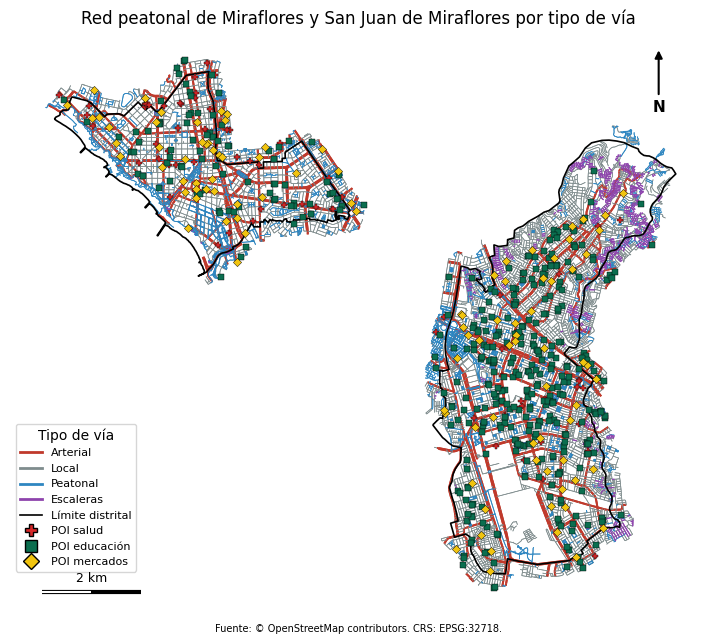

In [3]:
ESTILO = {"Arterial": ("#c0392b", 1.4), "Local": ("#7f8c8d", 0.5), "Peatonal": ("#2e86c1", 0.6), "Escaleras": ("#8e44ad", 0.8)}
fig, ax = plt.subplots(figsize=(9, 9))
for grupo, (color, lw) in ESTILO.items():
    aristas[aristas["grupo_via"] == grupo].plot(ax=ax, color=color, linewidth=lw)
limites_utm.boundary.plot(ax=ax, color="k", lw=1.2)
for capa, (color, marca) in {"salud": ("#d62728", "P"), "educacion": ("#0b6e4f", "s"), "mercados": ("#f1c40f", "D")}.items():
    p = gpd.GeoDataFrame(poi[poi["capa"] == capa], geometry=gpd.points_from_xy(poi.loc[poi["capa"] == capa, "x"], poi.loc[poi["capa"] == capa, "y"]), crs=cfg.CRS_METRIC)
    p.plot(ax=ax, color=color, marker=marca, markersize=18, edgecolor="k", linewidth=0.3, zorder=5)
ax.set_axis_off()
mapas.escala_y_norte(ax, 2000)
leyenda = [Line2D([0], [0], color=c, lw=2, label=g) for g, (c, _) in ESTILO.items()]
leyenda += [Line2D([0], [0], color="k", lw=1.2, label="Límite distrital")]
leyenda += [Line2D([0], [0], marker=m, color="w", markerfacecolor=c, markeredgecolor="k", markersize=8, label=f"POI {n}")
            for n, (c, m) in {"salud": ("#d62728", "P"), "educación": ("#0b6e4f", "s"), "mercados": ("#f1c40f", "D")}.items()]
ax.legend(handles=leyenda, loc="lower left", bbox_to_anchor=(0.0, 0.07), fontsize=8, frameon=True, title="Tipo de vía")
ax.set_title("Red peatonal de Miraflores y San Juan de Miraflores por tipo de vía")
ax.text(0.5, -0.01, "Fuente: © OpenStreetMap contributors. CRS: EPSG:32718.", transform=ax.transAxes, ha="center", va="top", fontsize=7)
mapas.guardar(fig, cfg.FIG_MAPS / "eda_01_red_por_tipo_via.png")
plt.show()

## 3. Densidades y estructura (normalizadas por área)

Para cada distrito se usan solo sus nodos y las aristas cuyo punto medio cae dentro de él.

- **Densidad de intersecciones:** nodos con `street_count ≥ 3` por km².
- **Calles sin salida:** nodos con `street_count = 1`.
- **Longitud de vía:** km de calle (cada calle cuenta una vez; el grafo dirigido las tiene en ambos sentidos).
- Se advierte que el área del distrito incluye terreno sin urbanizar (cerros, parques), que baja las densidades.

In [4]:
filas = {}
for d in DISTRITOS:
    n = nodos[nodos["distrito"] == d]
    e = aristas[aristas["distrito"] == d]
    A = area_km2[d]
    km = e["length"].sum() / 2 / 1000
    filas[d] = {
        "área (km²)": A,
        "nodos": len(n),
        "nodos / km²": len(n) / A,
        "intersecciones (grado ≥ 3)": int((n["street_count"] >= 3).sum()),
        "intersecciones / km²": (n["street_count"] >= 3).sum() / A,
        "% calles sin salida (grado 1)": (n["street_count"] == 1).mean() * 100,
        "longitud de vía (km)": km,
        "km de vía / km²": km / A,
        "longitud media de arista (m)": e["length"].mean(),
        "grado medio (street_count)": n["street_count"].mean(),
    }
tabla_dens = pd.DataFrame(filas)
tabla_dens.round(2)

,Miraflores,San Juan de Miraflores
área (km²),9.45,22.06
nodos,3841.00,9127.00
nodos / km²,406.62,413.64
intersecciones (grado ≥ 3),3217.00,8310.00
intersecciones / km²,340.56,376.62
% calles sin salida (grado 1),14.61,8.38
longitud de vía (km),269.60,644.28
km de vía / km²,28.54,29.20
longitud media de arista (m),47.15,46.44
grado medio (street_count),2.98,3.05


### Composición de la red por tipo de vía

Proporción de la **longitud** de vía por grupo (no del número de aristas, para no sobrevalorar los tramos cortos), y proporción de longitud con escaleras.

grupo_via               Arterial  Local  Peatonal  Escaleras  % con algún tramo de escalera
distrito                                                                                   
Miraflores                  25.8   46.9      27.1        0.2                            1.1
San Juan de Miraflores      17.6   61.2      16.3        4.9                            5.8


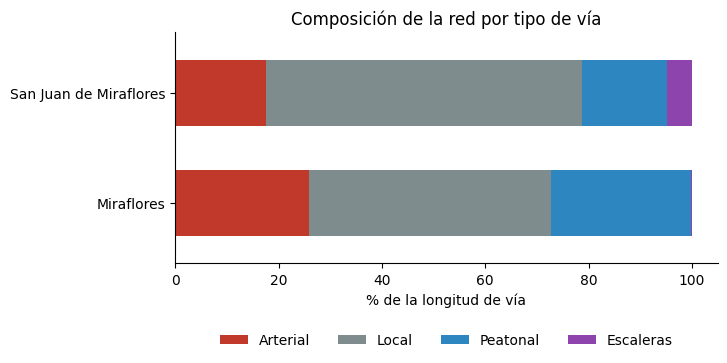

In [5]:
comp = (aristas[aristas["distrito"].isin(DISTRITOS)].groupby(["distrito", "grupo_via"])["length"].sum().unstack(fill_value=0))
comp_pct = comp.div(comp.sum(axis=1), axis=0).mul(100).loc[DISTRITOS, list(GRUPOS)]
esc = aristas[aristas["distrito"].isin(DISTRITOS)].groupby("distrito").apply(lambda g: g.loc[g["tiene_escalera"], "length"].sum() / g["length"].sum() * 100, include_groups=False)
comp_pct["% con algún tramo de escalera"] = esc.loc[DISTRITOS]
print(comp_pct.round(1).to_string())

fig, ax = plt.subplots(figsize=(7, 3))
comp_pct[list(GRUPOS)].plot.barh(stacked=True, ax=ax, color=[ESTILO[g][0] for g in GRUPOS], width=0.6)
ax.set_xlabel("% de la longitud de vía")
ax.set_ylabel("")
ax.set_title("Composición de la red por tipo de vía")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.25), frameon=False)
mapas.guardar(fig, cfg.FIG_PLOTS / "eda_04_composicion_vias.png")
plt.show()

### Distribución de la longitud de arista

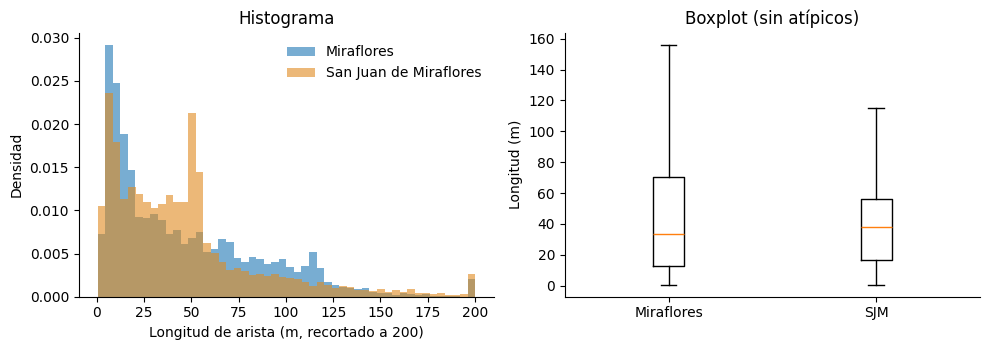

,count,mean,std,min,25%,50%,75%,max
distrito,,,,,,,,
Miraflores,11436.0,47.1,44.8,0.5,12.8,33.5,70.5,562.9
San Juan de Miraflores,27746.0,46.4,44.0,0.6,16.3,38.3,55.9,737.7


In [6]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3.6))
for d in DISTRITOS:
    s = aristas.loc[aristas["distrito"] == d, "length"]
    axs[0].hist(s.clip(upper=200), bins=50, alpha=0.6, color=COLOR_D[d], label=d, density=True)
axs[0].set(xlabel="Longitud de arista (m, recortado a 200)", ylabel="Densidad", title="Histograma")
axs[0].legend(frameon=False)
axs[1].boxplot([aristas.loc[aristas["distrito"] == d, "length"] for d in DISTRITOS], tick_labels=["Miraflores", "SJM"], showfliers=False)
axs[1].set(ylabel="Longitud (m)", title="Boxplot (sin atípicos)")
fig.tight_layout()
mapas.guardar(fig, cfg.FIG_PLOTS / "eda_03_longitudes.png")
plt.show()
aristas[aristas["distrito"].isin(DISTRITOS)].groupby("distrito")["length"].describe().loc[DISTRITOS].round(1)

## 4. Orientación de las calles

El rumbo de cada arista se calcula desde las coordenadas proyectadas de sus extremos (0° = norte). Se usan los dos sentidos de cada calle (el histograma es simétrico), 36 clases de 10° centradas en 0°, 10°… y ponderadas por longitud.

- **Entropía de orientación** *H* (Shannon, en nats): 0 si todas las calles tienen el mismo rumbo; ln 36 ≈ 3.58 si son uniformes; ln 4 ≈ 1.39 en una cuadrícula perfecta.
- **Índice de orden** φ = 1 − ((*H* − ln 4) / (ln 36 − ln 4))²: 1 es una cuadrícula perfecta y 0 un patrón uniforme.

In [7]:
xy = nodos[["x", "y"]]
u_xy = xy.loc[aristas["u"]].to_numpy()
v_xy = xy.loc[aristas["v"]].to_numpy()
aristas["rumbo"] = np.degrees(np.arctan2(v_xy[:, 0] - u_xy[:, 0], v_xy[:, 1] - u_xy[:, 1])) % 360

BINS = 36
def hist_orient(g):
    b = np.concatenate([g["rumbo"].to_numpy(), (g["rumbo"].to_numpy() + 180) % 360])
    w = np.concatenate([g["length"].to_numpy()] * 2)
    ancho = 360 / BINS
    h, _ = np.histogram((b + ancho / 2) % 360, bins=BINS, range=(0, 360), weights=w)
    return h

H_GRID, H_MAX = np.log(4), np.log(BINS)
orient, filas = {}, {}
for d in DISTRITOS:
    h = hist_orient(aristas[aristas["distrito"] == d])
    orient[d] = h
    H = entropy(h)
    filas[d] = {"entropía H (nats)": H, "índice de orden φ": 1 - ((H - H_GRID) / (H_MAX - H_GRID)) ** 2}
tabla_orient = pd.DataFrame(filas).T
print(f"Referencias: cuadrícula perfecta H = {H_GRID:.2f}, uniforme H = {H_MAX:.2f}")
tabla_orient.round(3)

Referencias: cuadrícula perfecta H = 1.39, uniforme H = 3.58


,entropía H (nats),índice de orden φ
Miraflores,3.413,0.149
San Juan de Miraflores,3.522,0.055


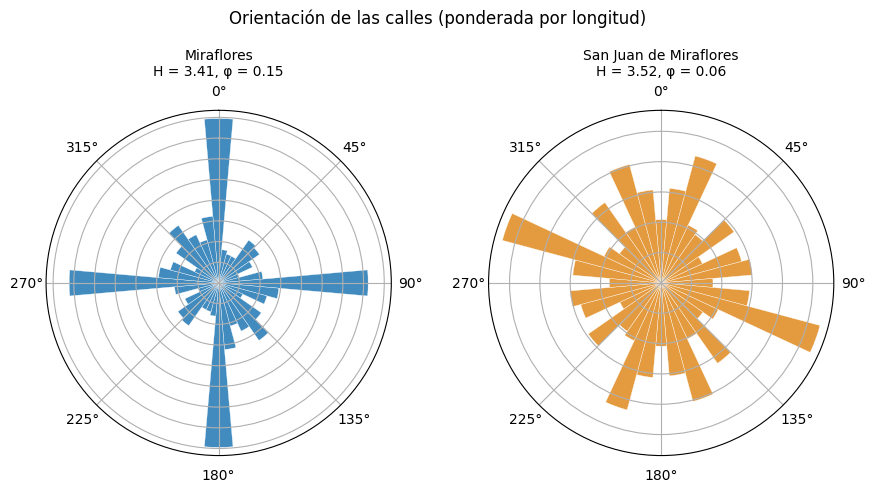

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(9, 4.6), subplot_kw={"projection": "polar"})
theta = np.deg2rad(np.arange(BINS) * 360 / BINS)
for ax, d in zip(axs, DISTRITOS):
    h = orient[d] / orient[d].sum()
    ax.bar(theta, h, width=np.deg2rad(360 / BINS), color=COLOR_D[d], alpha=0.85, edgecolor="white", linewidth=0.3)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_yticklabels([])
    ax.set_title(f"{d}\nH = {tabla_orient.loc[d, 'entropía H (nats)']:.2f}, φ = {tabla_orient.loc[d, 'índice de orden φ']:.2f}", fontsize=10)
fig.suptitle("Orientación de las calles (ponderada por longitud)", y=1.02)
fig.tight_layout()
mapas.guardar(fig, cfg.FIG_PLOTS / "eda_05_orientacion.png")
plt.show()

## 5. Distribución de los POI

Conteo de POI válidos por capa en cada distrito y densidad por km². Los POI del buffer no entran: pertenecen a distritos vecinos.

In [9]:
p = poi[poi["zona"].isin(DISTRITOS)]
cuenta = p.groupby(["zona", "capa"]).size().unstack(fill_value=0).loc[DISTRITOS]
dens = cuenta.div(area_km2.loc[DISTRITOS], axis=0)
nodos_poi = p.groupby(["zona", "capa"])["nodo_osmid"].nunique().unstack(fill_value=0).loc[DISTRITOS]
tabla_poi = pd.concat({"POI": cuenta, "POI / km²": dens.round(2), "nodos distintos": nodos_poi}, axis=1)
tabla_poi

POI                POI / km²                 \
capa                   educacion mercados salud educacion mercados salud   
zona                                                                       
Miraflores                    63       30    30      6.67     3.18  3.18   
San Juan de Miraflores       284       51    24     12.87     2.31  1.09   

                       nodos distintos                 
capa                         educacion mercados salud  
zona                                                   
Miraflores                          59       30    29  
San Juan de Miraflores             250       50    23

## 6. Calidad de los datos: dónde no hay red

Se divide el territorio de cada distrito en celdas de 100 m y se mide qué proporción **no es cruzada por ninguna arista**. Una proporción alta puede deberse a terreno no urbanizado (cerros, parques, zonas militares) o a vacíos de OpenStreetMap. Es relevante para el porcentaje de **superficie** cubierta en el Hito 2.

In [10]:
def grilla(lado):
    xmin, ymin, xmax, ymax = limites_utm.total_bounds
    xs, ys = np.arange(xmin, xmax, lado), np.arange(ymin, ymax, lado)
    celdas = gpd.GeoDataFrame(geometry=[box(x, y, x + lado, y + lado) for x in xs for y in ys], crs=cfg.CRS_METRIC)
    cj = gpd.sjoin(gpd.GeoDataFrame(geometry=celdas.geometry.centroid, crs=cfg.CRS_METRIC),
                   limites_utm[["distrito", "geometry"]], how="inner", predicate="within")
    return celdas.loc[cj.index].assign(distrito=cj["distrito"])

c100 = grilla(100)
toca = gpd.sjoin(c100[["geometry"]], aristas[["geometry"]], predicate="intersects").index.unique()
c100["con_red"] = c100.index.isin(toca)
sin_red = c100.groupby("distrito")["con_red"].agg(celdas="size", pct_sin_red=lambda s: (~s).mean() * 100).loc[DISTRITOS]
sin_red.round(1)

,celdas,pct_sin_red
distrito,,
Miraflores,944,3.5
San Juan de Miraflores,2204,6.8


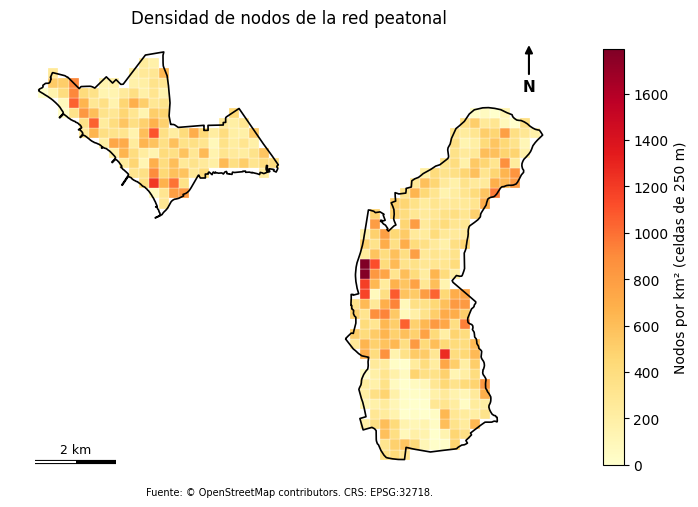

,count,mean,std,min,25%,50%,75%,max
distrito,,,,,,,,
Miraflores,149.0,404.0,228.0,0.0,240.0,352.0,512.0,1216.0
San Juan de Miraflores,353.0,408.0,258.0,0.0,240.0,368.0,528.0,1792.0


In [11]:
c250 = grilla(250)
lado_km2 = (250 / 1000) ** 2
cnt = gpd.sjoin(nodos[["geometry"]], c250[["geometry"]], predicate="within").groupby("index_right").size()
c250["nodos_km2"] = c250.index.map(cnt).to_series(index=c250.index).fillna(0).to_numpy() / lado_km2

fig, ax = plt.subplots(figsize=(9, 9))
c250.plot(ax=ax, column="nodos_km2", cmap="YlOrRd", legend=True, edgecolor="white", linewidth=0.2,
          legend_kwds={"label": "Nodos por km² (celdas de 250 m)", "shrink": 0.6})
limites_utm.boundary.plot(ax=ax, color="k", lw=1.2)
ax.set_axis_off()
mapas.escala_y_norte(ax, 2000)
ax.set_title("Densidad de nodos de la red peatonal")
ax.text(0.5, -0.01, "Fuente: © OpenStreetMap contributors. CRS: EPSG:32718.", transform=ax.transAxes, ha="center", va="top", fontsize=7)
mapas.guardar(fig, cfg.FIG_MAPS / "eda_02_densidad_nodos.png")
plt.show()
c250.groupby("distrito")["nodos_km2"].describe().loc[DISTRITOS].round(0)

## 7. Comparación Miraflores vs San Juan de Miraflores

Resumen de las métricas normalizadas por área.

In [12]:
resumen = pd.concat([
    tabla_dens.loc[["nodos / km²", "intersecciones / km²", "km de vía / km²", "longitud media de arista (m)", "% calles sin salida (grado 1)"]],
    comp_pct.T.loc[["Arterial", "Local", "Peatonal", "Escaleras", "% con algún tramo de escalera"]].rename(lambda s: f"% longitud {s.lower()}" if s in GRUPOS else s),
    tabla_orient.T,
    cuenta.T.div(area_km2.loc[DISTRITOS], axis=1).rename(lambda s: f"POI {s} / km²"),
    sin_red[["pct_sin_red"]].T.rename(index={"pct_sin_red": "% del área sin red (celdas de 100 m)"}),
])
resumen.round(2)

,Miraflores,San Juan de Miraflores
nodos / km²,406.62,413.64
intersecciones / km²,340.56,376.62
km de vía / km²,28.54,29.20
longitud media de arista (m),47.15,46.44
% calles sin salida (grado 1),14.61,8.38
% longitud arterial,25.84,17.60
% longitud local,46.94,61.20
% longitud peatonal,27.06,16.35
% longitud escaleras,0.16,4.85
% con algún tramo de escalera,1.06,5.76


In [13]:
resumen.round(3).to_csv(cfg.DATA_PROCESSED / "eda_comparacion_distritos.csv")
print("Guardado:", cfg.DATA_PROCESSED / "eda_comparacion_distritos.csv")

Guardado: D:\TP-TF_Complex_Networks\data\processed\eda_comparacion_distritos.csv


### Hallazgos del análisis exploratorio (paso 7)

1. **Densidad de red casi igual en ambos distritos:** 407 vs 414 nodos/km² y 28.5 vs 29.2 km de vía/km². La densidad de intersecciones es algo mayor en SJM (377 vs 341 por km²). Con densidades tan parecidas, las diferencias de accesibilidad vendrán sobre todo de **dónde está el equipamiento** y de la forma de la red, no de cuánta red hay.
2. **Composición distinta:** Miraflores tiene más vía arterial (25.8 % de la longitud frente a 17.6 %) y más vía peatonal (27.1 % frente a 16.3 %); SJM es más local (61.2 % frente a 46.9 %).
3. **Escaleras:** 4.9 % de la longitud de SJM son escaleras (5.8 % de la longitud tiene algún tramo de escalera) frente a 0.2 % en Miraflores. Es un indicador de relieve y de posible sobreestimación de la accesibilidad al usar velocidad constante (limitación a declarar).
4. **Orientación:** Miraflores muestra cuatro picos claros en las direcciones N–S y E–O (H = 3.41, φ = 0.15), propios de una cuadrícula; SJM no tiene dirección dominante (H = 3.52, φ = 0.06, casi uniforme), coherente con trazado adaptado a laderas. Los valores de φ son bajos en ambos; una posible causa (por verificar, p. ej. repitiendo el cálculo solo con vías vehiculares) es que la red peatonal incluye pasajes y senderos en todas las direcciones.
5. **Calles sin salida:** 14.6 % de los nodos de Miraflores frente a 8.4 % en SJM. Está por aclarar si se debe a pasajes peatonales o a terminaciones por el borde del grafo.
6. **Equipamiento:** SJM tiene casi el doble de colegios por km² (12.9 vs 6.7), pero Miraflores tiene más densidad de salud (3.2 vs 1.1 por km²) y de mercados (3.2 vs 2.3). La densidad por área no es lo mismo que acceso por habitante: sin población no se puede afirmar quién está mejor servido (Hito 2).
7. **Cobertura territorial de la red:** el 3.5 % del área de Miraflores y el 6.8 % de la de SJM no es cruzada por ninguna arista (celdas de 100 m). Es el terreno sin urbanizar o con vacíos en OSM, y debe tenerse en cuenta al calcular el % de **superficie** cubierta por las isócronas.
8. **Mapa de densidad:** la mayor concentración de nodos está en una zona del oeste de SJM (hasta ≈ 1 800 nodos/km² en celdas de 250 m); el centro-sur de SJM es el de menor densidad.

**Limitación de la normalización:** las densidades usan el área total del distrito, que incluye cerros, parques y terreno sin urbanizar; las densidades sobre el área urbanizada serían mayores, sobre todo en SJM.

## 8. Métricas globales y locales

Se calculan **por distrito**, sobre el subgrafo formado solo por los nodos de ese distrito (sin el buffer), no dirigido y simple (el grafo es simétrico, ver `02c`). Se toma su componente conexo gigante para las métricas de caminos.

- **Métricas globales:** nodos, aristas, grado medio, densidad del grafo, longitud de vía, intersecciones por km², circuity, eficiencia global, longitud media de camino, diámetro y componentes.
- **Métricas locales:** distribución de grado, coeficiente de agrupamiento, centralidades de grado, cercanía, intermediación y PageRank.
- Las métricas de caminos se calculan **exactas sobre todos los pares** de nodos (Dijkstra de `scipy`, por bloques). La **intermediación** se aproxima por muestreo de `k` orígenes (el enunciado lo admite si se declara `k` y se discute el error); el error se mide contra la intermediación exacta de Miraflores.

### 8.1 Subgrafos por distrito

In [14]:
import time
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra
from scipy.stats import spearmanr
from src import red

D = red.construir_digrafo(G, cfg.WALK_SPEED_KMH)
Gu = D.to_undirected()

K_BETW = 500          # orígenes muestreados para la intermediación aproximada
subg, filas = {}, []
for d in DISTRITOS:
    nd = [n for n, a in Gu.nodes(data=True) if a["distrito"] == d]
    H = Gu.subgraph(nd)
    comps = sorted(nx.connected_components(H), key=len, reverse=True)
    subg[d] = nx.Graph(H.subgraph(comps[0]))
    filas.append({"distrito": d, "nodos del distrito": len(nd), "componentes": len(comps),
                  "nodos en el componente gigante": len(comps[0]), "% en el gigante": round(len(comps[0]) / len(nd) * 100, 1)})
pd.DataFrame(filas).set_index("distrito")

,nodos del distrito,componentes,nodos en el componente gigante,% en el gigante
distrito,,,,
Miraflores,3841,15,3810,99.2
San Juan de Miraflores,9127,12,9103,99.7


### 8.2 Métricas estructurales (sin caminos)

In [15]:
est = {}
for d, H in subg.items():
    N, E = H.number_of_nodes(), H.number_of_edges()
    k_med = 2 * E / N
    grados = np.array([g for _, g in H.degree()])
    est[d] = {
        "nodos (componente gigante)": N,
        "aristas (calles, no dirigidas)": E,
        "grado medio ⟨k⟩": k_med,
        "grado máximo": grados.max(),
        "densidad del grafo 2E/(N(N−1))": 2 * E / (N * (N - 1)),
        "longitud de vía (km)": sum(a["length"] for _, _, a in H.edges(data=True)) / 1000,
        "intersecciones (grado ≥ 3) / km²": (grados >= 3).sum() / area_km2[d],
        "coef. de agrupamiento medio C": nx.average_clustering(H),
        "transitividad": nx.transitivity(H),
        "C de un grafo aleatorio ⟨k⟩/N": k_med / N,
    }
tabla_est = pd.DataFrame(est)
tabla_est.round(4)

,Miraflores,San Juan de Miraflores
nodos (componente gigante),3810.0000,9103.0000
"aristas (calles, no dirigidas)",5587.0000,13737.0000
grado medio ⟨k⟩,2.9328,3.0181
grado máximo,7.0000,6.0000
densidad del grafo 2E/(N(N−1)),0.0008,0.0003
longitud de vía (km),260.4545,634.5937
intersecciones (grado ≥ 3) / km²,326.0592,365.6499
coef. de agrupamiento medio C,0.0474,0.0238
transitividad,0.0579,0.0252
C de un grafo aleatorio ⟨k⟩/N,0.0008,0.0003


### 8.3 Métricas de caminos (todos los pares)

Para cada par de nodos del componente gigante se calcula la distancia por la red (m) y por saltos, y la distancia en línea recta.

- **Longitud media de camino** *L* y **diámetro** (la mayor distancia entre dos nodos), en metros y en saltos.
- **Circuity** (sinuosidad): cociente entre la distancia por la red y la distancia en línea recta, `Σ d_red / Σ d_recta`. Se da para todos los pares y para los pares a ≤ 1 200 m en línea recta, que es el alcance de una caminata de 15 min.
- **Eficiencia global** (Latora y Marchiori) relativa a la ideal: `Σ 1/d_red / Σ 1/d_recta`; vale 1 si todas las rutas fueran rectas.
- **Cercanía** exacta de cada nodo: `(N−1) / Σ_j d_ij`.

In [16]:
def todos_los_pares(H, bloque=400):
    nodos_l = list(H.nodes)
    idx = {n: i for i, n in enumerate(nodos_l)}
    n = len(nodos_l)
    f = [idx[u] for u, v in H.edges]
    c = [idx[v] for u, v in H.edges]
    w = [a["length"] for _, _, a in H.edges(data=True)]
    A = csr_matrix((w, (f, c)), shape=(n, n))
    X = np.array([H.nodes[m]["x"] for m in nodos_l])
    Y = np.array([H.nodes[m]["y"] for m in nodos_l])

    s_d = s_e = s_inv_d = s_inv_e = s_h = 0.0
    s_d_c = s_e_c = 0.0
    n_pares = 0
    d_max = h_max = 0.0
    suma_fila = np.zeros(n)
    for ini in range(0, n, bloque):
        ids = np.arange(ini, min(ini + bloque, n))
        Dm = dijkstra(A, directed=False, indices=ids)
        Hm = dijkstra(A, directed=False, indices=ids, unweighted=True)
        Em = np.hypot(X[ids, None] - X[None, :], Y[ids, None] - Y[None, :])
        mask = np.ones(Dm.shape, bool)
        mask[np.arange(len(ids)), ids] = False
        suma_fila[ids] = Dm.sum(axis=1)
        d, e, h = Dm[mask], Em[mask], Hm[mask]
        s_d += d.sum(); s_e += e.sum(); s_h += h.sum()
        s_inv_d += (1 / d).sum(); s_inv_e += (1 / e).sum()
        cerca = e <= 1200
        s_d_c += d[cerca].sum(); s_e_c += e[cerca].sum()
        n_pares += d.size
        d_max = max(d_max, d.max()); h_max = max(h_max, h.max())
    res = {
        "longitud media de camino (m)": s_d / n_pares,
        "diámetro (m)": d_max,
        "longitud media de camino (saltos)": s_h / n_pares,
        "diámetro (saltos)": h_max,
        "circuity, todos los pares": s_d / s_e,
        "circuity, pares a ≤ 1 200 m en línea recta": s_d_c / s_e_c,
        "eficiencia global relativa": s_inv_d / s_inv_e,
    }
    cercania = pd.Series((n - 1) / suma_fila, index=nodos_l)
    return res, cercania

caminos, cercania = {}, {}
for d, H in subg.items():
    t0 = time.time()
    caminos[d], cercania[d] = todos_los_pares(H)
    print(f"{d}: {H.number_of_nodes():,} nodos, {time.time() - t0:.0f} s")
tabla_caminos = pd.DataFrame(caminos)
tabla_caminos.round(3)

Miraflores: 3,810 nodos, 3 s


San Juan de Miraflores: 9,103 nodos, 16 s


,Miraflores,San Juan de Miraflores
longitud media de camino (m),2171.919,3553.186
diámetro (m),7562.358,11484.837
longitud media de camino (saltos),34.788,48.894
diámetro (saltos),107.000,141.000
"circuity, todos los pares",1.184,1.247
"circuity, pares a ≤ 1 200 m en línea recta",1.260,1.368
eficiencia global relativa,0.804,0.768


#### Contraste con un grafo aleatorio

Una red de mundo pequeño tiene longitud de camino en saltos *L* ≈ ln *N* / ln⟨*k*⟩ y agrupamiento *C* mucho mayor que el de un grafo aleatorio. Se compara con los valores observados.

In [17]:
cmp = pd.DataFrame({
    d: {
        "N": subg[d].number_of_nodes(),
        "⟨k⟩": tabla_est.loc["grado medio ⟨k⟩", d],
        "L observada (saltos)": tabla_caminos.loc["longitud media de camino (saltos)", d],
        "L aleatorio ln N / ln⟨k⟩": np.log(subg[d].number_of_nodes()) / np.log(tabla_est.loc["grado medio ⟨k⟩", d]),
        "C observado": tabla_est.loc["coef. de agrupamiento medio C", d],
        "C aleatorio ⟨k⟩/N": tabla_est.loc["C de un grafo aleatorio ⟨k⟩/N", d],
    } for d in DISTRITOS
})
cmp.loc["razón L (observada / aleatoria)"] = cmp.loc["L observada (saltos)"] / cmp.loc["L aleatorio ln N / ln⟨k⟩"]
cmp.loc["razón C (observado / aleatorio)"] = cmp.loc["C observado"] / cmp.loc["C aleatorio ⟨k⟩/N"]
cmp.round(4)

,Miraflores,San Juan de Miraflores
N,3810.0000,9103.0000
⟨k⟩,2.9328,3.0181
L observada (saltos),34.7883,48.8941
L aleatorio ln N / ln⟨k⟩,7.6633,8.2528
C observado,0.0474,0.0238
C aleatorio ⟨k⟩/N,0.0008,0.0003
razón L (observada / aleatoria),4.5396,5.9245
razón C (observado / aleatorio),61.5565,71.6780


### 8.4 Distribución de grado

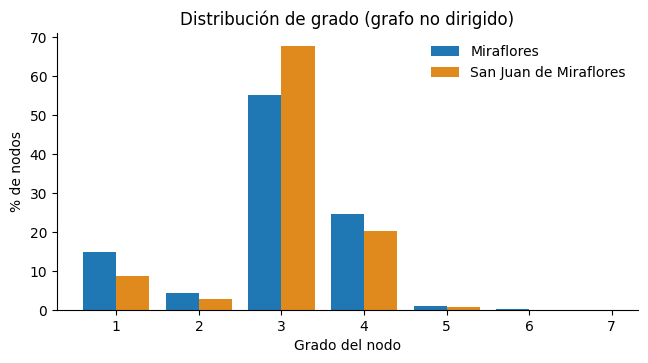

,Miraflores,San Juan de Miraflores
1,14.8,8.6
2,4.4,2.8
3,55.1,67.7
4,24.5,20.1
5,0.9,0.8
6,0.3,0.0
7,0.0,0.0


In [18]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ancho = 0.4
for i, d in enumerate(DISTRITOS):
    gr = pd.Series([g for _, g in subg[d].degree()]).value_counts(normalize=True).sort_index()
    ax.bar(gr.index + (i - 0.5) * ancho, gr.values * 100, width=ancho, color=COLOR_D[d], label=d)
ax.set(xlabel="Grado del nodo", ylabel="% de nodos", title="Distribución de grado (grafo no dirigido)")
ax.legend(frameon=False)
mapas.guardar(fig, cfg.FIG_PLOTS / "metricas_01_distribucion_grado.png")
plt.show()
pd.DataFrame({d: pd.Series([g for _, g in subg[d].degree()]).value_counts(normalize=True).sort_index().mul(100).round(1) for d in DISTRITOS}).fillna(0)

### 8.5 Centralidades locales

- **Grado** y **agrupamiento** de cada nodo.
- **Cercanía:** exacta (8.3).
- **Intermediación** (*betweenness*): aproximada con `K_BETW` = 500 orígenes muestreados y ponderada por longitud; semilla fija. Normalizada por (N−1)(N−2)/2.
- **PageRank:** sobre el grafo no dirigido, sin pesos (un peso mayor en PageRank significa un enlace más fuerte, lo contrario de una distancia).

In [19]:
locales = {}
for d, H in subg.items():
    t0 = time.time()
    df = pd.DataFrame(index=list(H.nodes))
    df["distrito"] = d
    df["x"] = [H.nodes[n]["x"] for n in df.index]
    df["y"] = [H.nodes[n]["y"] for n in df.index]
    df["grado"] = pd.Series(dict(H.degree()))
    df["agrupamiento"] = pd.Series(nx.clustering(H))
    df["cercania"] = cercania[d]
    df["intermediacion"] = pd.Series(nx.betweenness_centrality(H, k=K_BETW, weight="length", seed=cfg.SEED, normalized=True))
    df["pagerank"] = pd.Series(nx.pagerank(H, weight=None))
    locales[d] = df
    print(f"{d}: centralidades en {time.time() - t0:.0f} s")
nodos_metricas = pd.concat(locales.values())
nodos_metricas.groupby("distrito")[["grado", "agrupamiento", "cercania", "intermediacion", "pagerank"]].describe().T.round(5)

Miraflores: centralidades en 6 s


San Juan de Miraflores: centralidades en 18 s


distrito              Miraflores  San Juan de Miraflores
grado          count  3810.00000              9103.00000
               mean      2.93281                 3.01813
               std       0.96931                 0.77833
               min       1.00000                 1.00000
               25%       3.00000                 3.00000
               50%       3.00000                 3.00000
               75%       4.00000                 3.00000
               max       7.00000                 6.00000
agrupamiento   count  3810.00000              9103.00000
               mean      0.04738                 0.02377
               std       0.11539                 0.08740
               min       0.00000                 0.00000
               25%       0.00000                 0.00000
               50%       0.00000                 0.00000
               75%       0.00000                 0.00000
               max       1.00000                 1.00000
cercania       count  3810.00000              9103.00000
               mean      0.00048                 0.00030
               std       0.00009                 0.00006
               min       0.00024                 0.00015
               25%       0.00041                 0.00024
               50%       0.00049                 0.00030
               75%       0.00055                 0.00035
               max       0.00066                 0.00040
intermediacion count  3810.00000              9103.00000
               mean      0.01190                 0.00766
               std       0.01924                 0.01596
               min       0.00000                 0.00000
               25%       0.00059                 0.00028
               50%       0.00416                 0.00184
               75%       0.01459                 0.00681
               max       0.13657                 0.18184
pagerank       count  3810.00000              9103.00000
               mean      0.00026                 0.00011
               std       0.00007                 0.00002
               min       0.00011                 0.00004
               25%       0.00024                 0.00010
               50%       0.00027                 0.00011
               75%       0.00031                 0.00012
               max       0.00051                 0.00020

### 8.6 Error de la intermediación aproximada

Se compara, en Miraflores, la intermediación **exacta** con la aproximada para varios `k` (misma semilla), mediante:
- la correlación de rangos de Spearman (todos los nodos),
- la coincidencia (índice de Jaccard) del 5 % de nodos más centrales,
- el error absoluto medio relativo al máximo.

In [20]:
HM = subg["Miraflores"]
t0 = time.time()
exacta = pd.Series(nx.betweenness_centrality(HM, k=None, weight="length", normalized=True))
print(f"Intermediación exacta de Miraflores ({HM.number_of_nodes():,} nodos): {time.time() - t0:.0f} s")

def top(s, frac=0.05):
    return set(s.nlargest(int(len(s) * frac)).index)

filas = []
for k in (100, 250, 500, 1000):
    aprox = pd.Series(nx.betweenness_centrality(HM, k=k, weight="length", seed=cfg.SEED, normalized=True))
    a, b = top(exacta), top(aprox)
    filas.append({"k": k, "% de los nodos como orígenes": round(k / HM.number_of_nodes() * 100, 1),
                  "Spearman": spearmanr(exacta, aprox.reindex(exacta.index)).statistic,
                  "Jaccard del top 5 %": len(a & b) / len(a | b),
                  "error abs. medio / máximo": (aprox.reindex(exacta.index) - exacta).abs().mean() / exacta.max()})
tabla_error = pd.DataFrame(filas).set_index("k")
tabla_error.round(3)

Intermediación exacta de Miraflores (3,810 nodos): 47 s


,% de los nodos como orígenes,Spearman,Jaccard del top 5 %,error abs. medio / máximo
k,,,,
100,2.6,0.973,0.854,0.017
250,6.6,0.981,0.891,0.011
500,13.1,0.989,0.910,0.007
1000,26.2,0.995,0.939,0.005


### 8.7 Mapas de centralidad

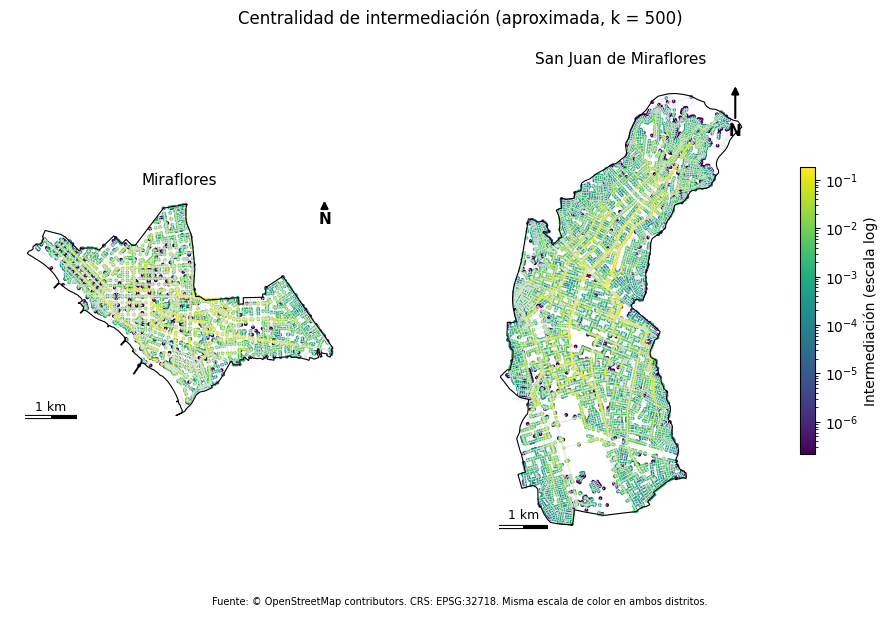

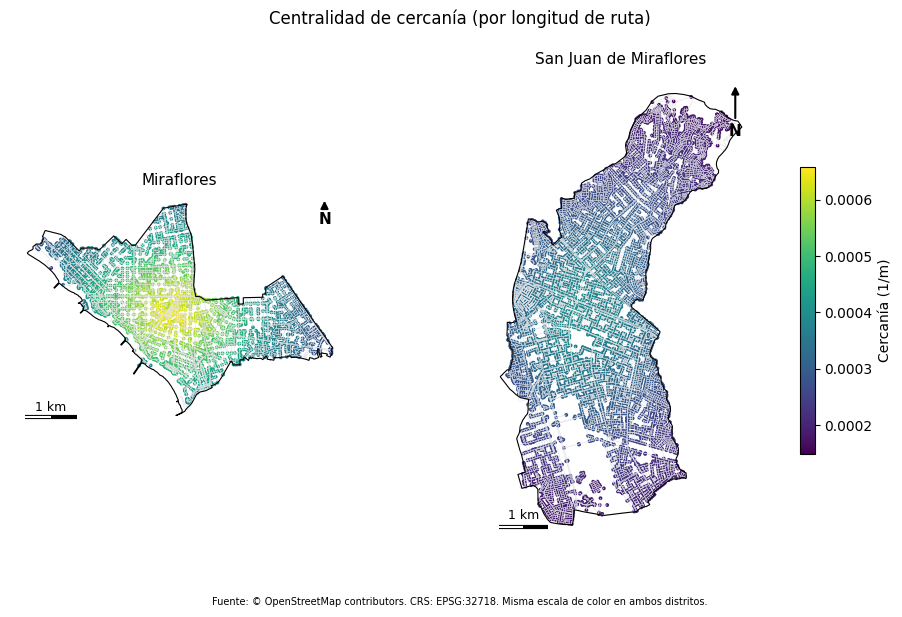

In [21]:
from matplotlib.colors import LogNorm

def mapa_centralidad(col, titulo, etiqueta, archivo, log=False):
    fig, axs = plt.subplots(1, 2, figsize=(12, 6.2))
    vmin = nodos_metricas[col][nodos_metricas[col] > 0].min() if log else nodos_metricas[col].min()
    vmax = nodos_metricas[col].max()
    norm = LogNorm(vmin, vmax) if log else None
    for ax, d in zip(axs, DISTRITOS):
        df = nodos_metricas[nodos_metricas["distrito"] == d].sort_values(col)
        aristas[aristas["distrito"] == d].plot(ax=ax, color="#e3e5e8", linewidth=0.3)
        limites_utm[limites_utm["distrito"] == d].boundary.plot(ax=ax, color="k", lw=0.8)
        sc = ax.scatter(df["x"], df["y"], c=df[col].clip(lower=vmin) if log else df[col], s=3, cmap="viridis",
                        norm=norm, vmin=None if log else vmin, vmax=None if log else vmax)
        ax.set_axis_off()
        ax.set_title(d, fontsize=11)
        mapas.escala_y_norte(ax, 1000)
    fig.colorbar(sc, ax=axs, shrink=0.6, label=etiqueta + (" (escala log)" if log else ""))
    fig.suptitle(titulo)
    fig.text(0.5, 0.02, "Fuente: © OpenStreetMap contributors. CRS: EPSG:32718. Misma escala de color en ambos distritos.", ha="center", fontsize=7)
    mapas.guardar(fig, cfg.FIG_MAPS / archivo)
    plt.show()

mapa_centralidad("intermediacion", "Centralidad de intermediación (aproximada, k = 500)", "Intermediación", "metricas_02_intermediacion.png", log=True)
mapa_centralidad("cercania", "Centralidad de cercanía (por longitud de ruta)", "Cercanía (1/m)", "metricas_03_cercania.png")

### 8.8 Resumen y exportación

In [22]:
globales = pd.concat([tabla_est, tabla_caminos])
globales.round(4).to_csv(cfg.DATA_PROCESSED / "metricas_globales.csv")
nodos_metricas.index.name = "osmid"
nodos_metricas.round(6).to_csv(cfg.DATA_PROCESSED / "metricas_nodos.csv")
tabla_error.round(4).to_csv(cfg.DATA_PROCESSED / "metricas_error_betweenness.csv")
print({p.name: f"{p.stat().st_size / 1e6:.1f} MB" for p in cfg.DATA_PROCESSED.glob("metricas_*.csv")})
globales.round(3)

{'metricas_error_betweenness.csv': '0.0 MB', 'metricas_globales.csv': '0.0 MB', 'metricas_nodos.csv': '1.2 MB'}


,Miraflores,San Juan de Miraflores
nodos (componente gigante),3810.000,9103.000
"aristas (calles, no dirigidas)",5587.000,13737.000
grado medio ⟨k⟩,2.933,3.018
grado máximo,7.000,6.000
densidad del grafo 2E/(N(N−1)),0.001,0.000
longitud de vía (km),260.454,634.594
intersecciones (grado ≥ 3) / km²,326.059,365.650
coef. de agrupamiento medio C,0.047,0.024
transitividad,0.058,0.025
C de un grafo aleatorio ⟨k⟩/N,0.001,0.000


### Hallazgos de las métricas (paso 8)

**Estructura (Miraflores / SJM)**
1. **Sin hubs, grado casi constante:** ⟨k⟩ = 2.93 / 3.02 y grado máximo 7 / 6. El 55 % / 68 % de los nodos tiene grado 3 y el 25 % / 20 % grado 4; los nodos de grado 1 (calles sin salida) son el 14.8 % / 8.6 %. Es el comportamiento esperado de una red espacial planar: no hay distribución de cola larga (*scale-free*).
2. **No es una red de mundo pequeño:** la longitud media de camino en saltos es 34.8 / 48.9, entre 4.5 y 5.9 veces la de un grafo aleatorio equivalente (7.7 / 8.3), aunque el agrupamiento (C = 0.047 / 0.024) es 62 y 72 veces mayor. Alto agrupamiento con caminos largos es la firma de una red regular, tipo malla: moverse entre dos puntos exige recorrer distancia física, no hay atajos.
3. **Agrupamiento bajo:** la mediana es 0 y más del 75 % de los nodos no forma ningún triángulo, como corresponde a una red de calles (cuadrículas sin triángulos).
4. **Distancias:** longitud media de camino 2.17 km / 3.55 km, diámetro 7.6 km / 11.5 km (107 / 141 saltos). La red de SJM es más extensa y alargada.

**Eficiencia y circuity**
5. **Circuity** de 1.18 / 1.25 para todos los pares, pero **1.26 / 1.37 para pares a ≤ 1 200 m en línea recta**: en los trayectos cortos, los que importan a pie, el rodeo es mayor. Como orden de magnitud, una caminata de 1 200 m por la red alcanza en línea recta unos 950 m en Miraflores y unos 880 m en SJM (1 200 / circuity); esto anticipa que las isócronas de 15 min cubrirán menos área de lo que sugiere un círculo de 1.2 km.
6. **Eficiencia global relativa** de 0.80 / 0.77: la red tiene un rendimiento algo mejor en Miraflores, coherente con su trazado más ortogonal y menos accidentado (EDA, sección 4).

**Centralidades locales**
7. **Cercanía:** en Miraflores es máxima en el centro del distrito y cae hacia los extremos; en SJM crece hacia el eje central y es mínima en los extremos norte y sur. **No son comparables en valor absoluto entre distritos** (depende del tamaño de la red: máx. 0.00066 frente a 0.00040); se comparan los patrones.
8. **Intermediación:** muy concentrada: la mediana es 0.004 / 0.002 y el máximo 0.137 / 0.182. El mapa muestra que los valores altos siguen unos pocos ejes arteriales, que concentran las rutas más cortas y son los puntos críticos de la red. Tampoco es comparable en valor absoluto entre distritos.
9. **PageRank** casi uniforme (de 0.00011 a 0.00051 en Miraflores), sin nodos dominantes, consistente con la ausencia de hubs.

**Error de la intermediación aproximada** (comparada con la exacta de Miraflores)

| k | Spearman | Jaccard del top 5 % | Error abs. medio / máx. |
|---:|---:|---:|---:|
| 100 | 0.973 | 0.854 | 1.7 % |
| 250 | 0.981 | 0.891 | 1.1 % |
| 500 | 0.989 | 0.910 | 0.7 % |
| 1000 | 0.995 | 0.939 | 0.5 % |

Con `k = 500` el ranking se reproduce casi igual (Spearman 0.989) y el 91 % de los nodos más centrales coincide. El error se midió solo en Miraflores (13 % de los nodos como orígenes); en SJM, `k = 500` es el 5.5 % de los nodos, por lo que el error podría ser algo mayor y no se midió.

**Notas metodológicas**
- Las métricas de caminos usan solo los nodos de cada distrito (componente gigante: 99.2 % y 99.7 %), sin pasar por el buffer; por eso la densidad de intersecciones (326 / 366 por km², grado ≥ 3 en el grafo simple no dirigido del componente gigante) difiere algo de la del análisis exploratorio (341 / 377, que usa `street_count` de todos los nodos del distrito).
- Las centralidades de cercanía e intermediación dependen del tamaño de la red; para comparar distritos se usan sus patrones espaciales y no sus valores absolutos.